Importing Dataset from Github

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import requests
import os
from zipfile import ZipFile
from io import BytesIO

# Replace with your GitHub dataset link
github_url = "https://github.com/spMohanty/PlantVillage-Dataset/archive/442d23a8a486febaad5c91e3c13ce30d4cd302ca.zip"

# Define the download and extraction paths
download_path = "/content/plantvillage.zip"  # Change to your desired download path
extract_path = "/content/plantvillage"  # Change to your desired extraction path

# Download the dataset
response = requests.get(github_url)
with open(download_path, "wb") as f:
    f.write(response.content)

# Extract the downloaded zip file
with ZipFile(download_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Remove the downloaded zip file
os.remove(download_path)

# List all subfolders (classes) in the dataset
class_folders = os.listdir(os.path.join(extract_path, "PlantVillage-Dataset-442d23a8a486febaad5c91e3c13ce30d4cd302ca", "raw", "color"))

# Print the list of class folders
print("Class folders:", class_folders)


Class folders: ['Squash___Powdery_mildew', 'Peach___healthy', 'Grape___Esca_(Black_Measles)', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Late_blight', 'Apple___Cedar_apple_rust', 'Tomato___Septoria_leaf_spot', 'Tomato___Target_Spot', 'Apple___Black_rot', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Grape___healthy', 'Apple___Apple_scab', 'Pepper,_bell___Bacterial_spot', 'Apple___healthy', 'Tomato___Tomato_mosaic_virus', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Orange___Haunglongbing_(Citrus_greening)', 'Raspberry___healthy', 'Strawberry___healthy', 'Potato___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Leaf_Mold', 'Potato___Early_blight', 'Pepper,_bell___healthy', 'Strawberry___Leaf_scorch', 'Soybean___healthy', 'Peach___Bacterial_spot', 'Grape___Black_rot', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Early_blight', 'Potato___Late_blight', 'Tomato___hea

**Spliting the data into train test and split**

In [ ]:
import random
import shutil
import os

random.seed(42)
# Set the paths to your source data and destination directories
source_data_dir = '/content/plantvillage/PlantVillage-Dataset-442d23a8a486febaad5c91e3c13ce30d4cd302ca/raw/color'  # Path to your data folders
train_dir = '/content/drive/MyDrive/plantdata2/train'  # Destination for training data
valid_dir = '/content/drive/MyDrive/plantdata2/valid'  # Destination for validation data
test_dir = '/content/drive/MyDrive/plantdata2/test'    # Destination for test data

# Create destination directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Define split ratios (e.g., 60% train, 20% validation, 20% test)
split_ratio_train = 0.6
split_ratio_valid = 0.2

# Loop through each class folder in the source directory
class_folders = os.listdir(source_data_dir)
for class_folder in class_folders:
    class_path = os.path.join(source_data_dir, class_folder)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        num_images = len(images)
        num_train = int(num_images * split_ratio_train)
        num_valid = int(num_images * split_ratio_valid)

        # Randomly shuffle the images
        random.shuffle(images)

        # Move images to train directory
        for image in images[:num_train]:
            src_path = os.path.join(class_path, image)
            dest_path = os.path.join(train_dir, class_folder, image)
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            shutil.copy(src_path, dest_path)

        # Move images to validation directory
        for image in images[num_train:num_train + num_valid]:
            src_path = os.path.join(class_path, image)
            dest_path = os.path.join(valid_dir, class_folder, image)
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            shutil.copy(src_path, dest_path)

        # Move remaining images to test directory
        for image in images[num_train + num_valid:]:
            src_path = os.path.join(class_path, image)
            dest_path = os.path.join(test_dir, class_folder, image)
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            shutil.copy(src_path, dest_path)

print("Data splitting completed.")


Data splitting completed.


In [ ]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import numpy as np
import torchvision.models
import glob
import pathlib
import torch.optim
from torch.optim import lr_scheduler
from torchvision import transforms, datasets, models
import torch.optim as optim


**Data Processing **  1m 52 s cpu

In [ ]:
# Define the transformation pipeline
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
    # transforms.Normalize([1, 1, 1], [1, 1, 1]) normalization make the brightness decress
])

# Correct the usage of the 'transform' variable
train_data = torchvision.datasets.ImageFolder("/content/drive/MyDrive/plantdata2/train", transform=transform)
test_data = torchvision.datasets.ImageFolder("/content/drive/MyDrive/plantdata2/test", transform=transform)
val_data = torchvision.datasets.ImageFolder("/content/drive/MyDrive/plantdata2/valid", transform=transform)



Loading to Data Loader wiht a batch size of 32

In [ ]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)
valid_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)

batch 32 take 26 s

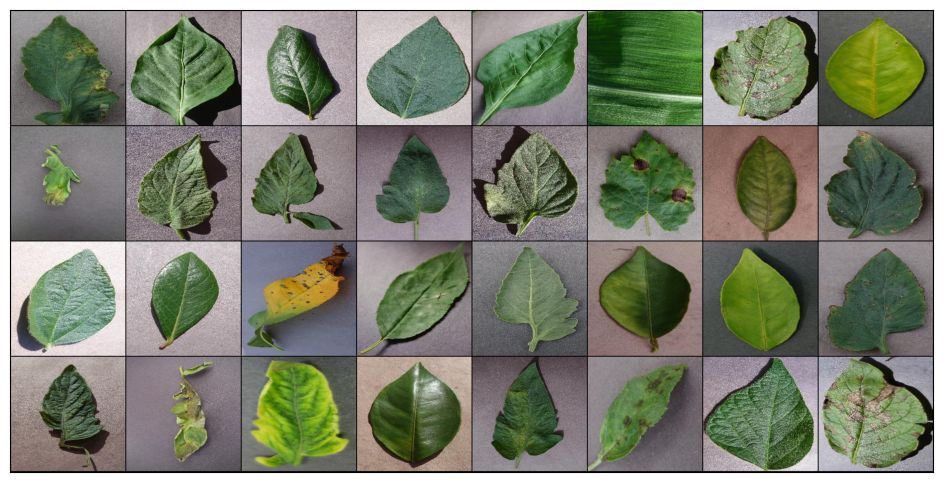

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12,6))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=8).permute(1, 2, 0))
        break
show_batch(train_loader)

In [ ]:
model=torchvision.models.resnet18(pretrained=True)
for p in model.parameters():
  p.requires_grad=False

num_ftrs=model.fc.in_features
dropout_prob = 0.05  # Adjust as needed

model.fc = nn.Sequential(
    nn.Dropout(p=dropout_prob),
    nn.Linear(num_ftrs, 38)  # Assuming 38 classes in your dataset
)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 261MB/s]


**Loading the weights which are trained before.**

In [ ]:
# weights_path_adam = '/content/drive/MyDrive/Resnet18/Resnet18_adam.pth'  # Change this to the desired file

# # Load the model and map it to the CPU
# model.load_state_dict(torch.load(weights_path_adam, map_location=torch.device('cuda'))) ##write condition if cuda available

# # Set the model in evaluation mode
# model.eval()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt
import numpy as np

Train the model using adam optimizer

In [ ]:
# Define loss function and optimizer
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
step_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Training loop
num_epochs = 8  # Adjust as needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_accuracies = []  # List to store training accuracies
val_accuracies = []    # List to store validation accuracies
train_losses = []  # List to store training losses
val_losses = []    # List to store validation losses

prev_train_accuracy = 0.0
min_accuracy_difference = 0.005  # Set your desired minimum accuracy difference

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train_predictions = 0
    total_train_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        total_train_samples += labels.size(0)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss_value = loss(outputs, labels)
        loss_value.backward()
        optimizer.step()

        running_loss += loss_value.item() * inputs.size(0)

        _, train_predicted = torch.max(outputs, 1)
        correct_train_predictions += torch.sum(train_predicted == labels.data)

    epoch_loss = running_loss / total_train_samples
    train_accuracy = correct_train_predictions.double() / total_train_samples

    # Validation
    model.eval()
    val_running_loss = 0.0
    correct_val_predictions = 0

    with torch.no_grad():
        for val_inputs, val_labels in valid_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model(val_inputs)
            val_loss_value = loss(val_outputs, val_labels)
            val_running_loss += val_loss_value.item() * val_inputs.size(0)

            _, val_predicted = torch.max(val_outputs, 1)
            correct_val_predictions += torch.sum(val_predicted == val_labels.data)

    val_epoch_loss = val_running_loss / len(val_data)
    val_accuracy = correct_val_predictions.double() / len(val_data)

    print(f"Epoch [{epoch}], train_loss: {epoch_loss:.4f}, val_loss: {val_epoch_loss:.4f}, train_acc: {train_accuracy:.4f}, val_acc: {val_accuracy:.4f}")

    train_accuracies.append(train_accuracy.item())
    val_accuracies.append(val_accuracy.item())
    train_losses.append(epoch_loss)
    val_losses.append(val_epoch_loss)

    step_lr_scheduler.step()

    # Check if the difference between consecutive training accuracies is less than the minimum
    if epoch > 0 and np.abs(train_accuracy.item() - prev_train_accuracy) < min_accuracy_difference:
        print(f"Training stopped as the difference in training accuracy between epoch {epoch} and {epoch - 1} is less than {min_accuracy_difference}.")
        break

    prev_train_accuracy = train_accuracy.item()

print("Training complete.")


Epoch [0], train_loss: 0.6931, val_loss: 0.2361, train_acc: 0.8449, val_acc: 0.9426
Epoch [1], train_loss: 0.2442, val_loss: 0.1722, train_acc: 0.9338, val_acc: 0.9537
Epoch [2], train_loss: 0.1898, val_loss: 0.1507, train_acc: 0.9451, val_acc: 0.9568
Epoch [3], train_loss: 0.1701, val_loss: 0.1302, train_acc: 0.9485, val_acc: 0.9596
Training stopped as the difference in training accuracy between epoch 3 and 2 is less than 0.005.
Training complete.


In [ ]:
# Plotting the accuracy and loss graphs
epochs_range = range(epoch+1)
plt.figure(figsize=(12, 4))

# Subplot for accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracies')

# Subplot for loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')

plt.tight_layout()
plt.show()

<ipython-input-14-13d8c3ca1418>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:.0f}%'.format(x) for x in plt.gca().get_yticks()])


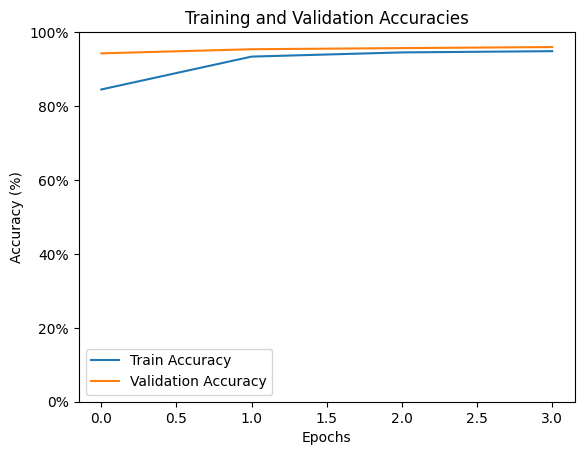

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(epoch+1)
plt.plot(epochs_range, [acc * 100 for acc in train_accuracies], label='Train Accuracy')
plt.plot(epochs_range, [acc * 100 for acc in val_accuracies], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracies')

# Set y-axis lower limit to 0 and upper limit to 100
plt.ylim(0, 100)

# Format y-axis tick labels as percentages
plt.gca().set_yticklabels(['{:.0f}%'.format(x) for x in plt.gca().get_yticks()])

plt.show()


In [33]:
torch.save(model.state_dict(), "/content/drive/MyDrive/Resnet/Resnet18_adam.pth")


Test the model

In [ ]:
correct_predictions = [0] * 38  # To keep track of correct predictions for each class
total_samples = [0] * 38  # To keep track of total samples for each class

model.eval()  # Set the model to evaluation mode


with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        # Update statistics for each class
        for i in range(len(predicted)):
            total_samples[labels[i]] += 1
            if predicted[i] == labels[i]:
                correct_predictions[labels[i]] += 1

# Calculate and print performance for each class
for i in range(38):
    accuracy = correct_predictions[i] / total_samples[i] if total_samples[i] > 0 else 0
    print(f"Class {class_folders[i]}: \n\t Accuracy = {accuracy:.2%} ({correct_predictions[i]}/{total_samples[i]})")

overall_accuracy = sum(correct_predictions) / sum(total_samples)
print(f"\nOverall Accuracy: {overall_accuracy:.2%}")

Class Squash___Powdery_mildew: 
	 Accuracy = 93.65% (118/126)
Class Peach___healthy: 
	 Accuracy = 97.60% (122/125)
Class Grape___Esca_(Black_Measles): 
	 Accuracy = 96.36% (53/55)
Class Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 
	 Accuracy = 97.26% (320/329)
Class Tomato___Late_blight: 
	 Accuracy = 99.34% (299/301)
Class Apple___Cedar_apple_rust: 
	 Accuracy = 98.58% (208/211)
Class Tomato___Septoria_leaf_spot: 
	 Accuracy = 99.42% (171/172)
Class Tomato___Target_Spot: 
	 Accuracy = 91.35% (95/104)
Class Apple___Black_rot: 
	 Accuracy = 98.33% (235/239)
Class Cherry_(including_sour)___healthy: 
	 Accuracy = 76.65% (151/197)
Class Cherry_(including_sour)___Powdery_mildew: 
	 Accuracy = 100.00% (233/233)
Class Grape___healthy: 
	 Accuracy = 97.88% (231/236)
Class Apple___Apple_scab: 
	 Accuracy = 96.40% (268/278)
Class Pepper,_bell___Bacterial_spot: 
	 Accuracy = 99.54% (215/216)
Class Apple___healthy: 
	 Accuracy = 97.67% (84/86)
Class Tomato___Tomato_mosaic_virus: 
	 Accura

In [ ]:
true_labels = []
test_predictions = []

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        test_predictions.extend(predicted.cpu().numpy())

In [ ]:
# Calculate F1 score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

test_predictions = np.array(test_predictions)
true_labels = np.array(true_labels)

f1_micro = f1_score(true_labels, test_predictions, average='micro')
f1_macro = f1_score(true_labels, test_predictions, average='macro')

print(f"F1 Micro Score: {f1_micro:.4f}")
print(f"F1 Macro Score: {f1_macro:.4f}")

# Confusion Matrix
precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(true_labels, test_predictions, average='micro')

print("Overall Metrics (Micro-average):")
print(f"\t Precision = {precision_micro:.4f}")
print(f"\t Recall    = {recall_micro:.4f}")
print(f"\t F1 Score  = {f1_micro:.4f}")
# Print or visualize the confusion matrix
conf_matrix = confusion_matrix(true_labels, test_predictions, labels=range(38))

print("Confusion Matrix:")
print(conf_matrix)


F1 Micro Score: 0.9598
F1 Macro Score: 0.9493
Overall Metrics (Micro-average):
	 Precision = 0.9598
	 Recall    = 0.9598
	 F1 Score  = 0.9598
Confusion Matrix:
[[ 120    2    1 ...    0    0    0]
 [   1  122    0 ...    0    1    0]
 [   2    0   52 ...    0    0    0]
 ...
 [   0    0    0 ... 1060    0    0]
 [   0    0    0 ...    0   72    0]
 [   0    0    0 ...    0    0  315]]


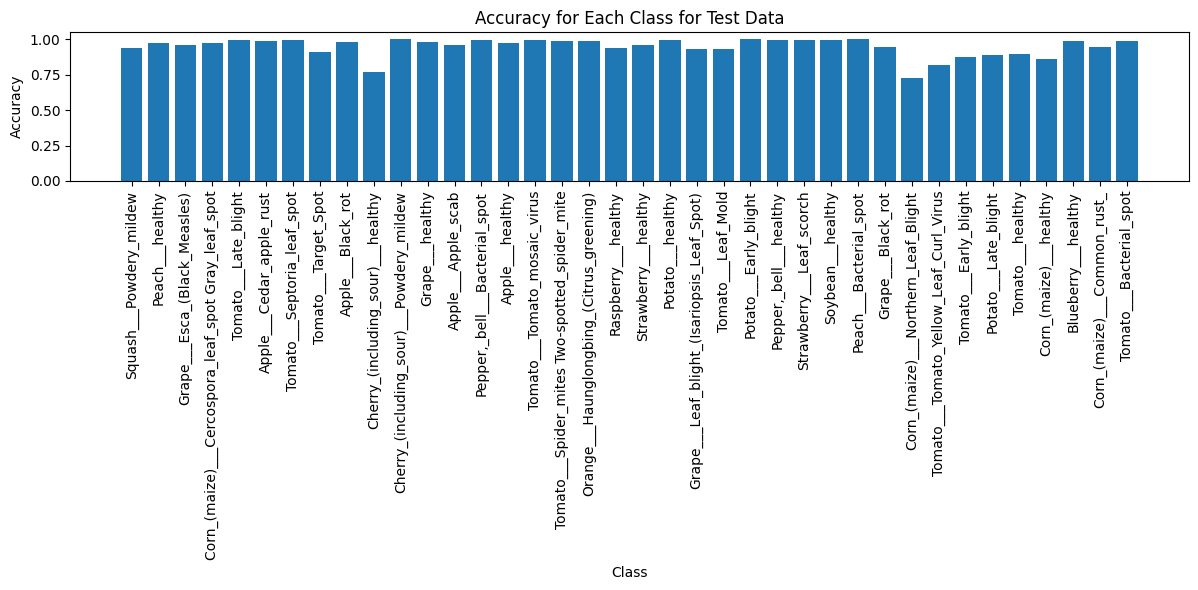

In [ ]:
import matplotlib.pyplot as plt

# Calculate accuracy values for each class
class_accuracy = [correct_predictions[i] / total_samples[i] if total_samples[i] > 0 else 0 for i in range(38)]

# Plotting the bar graph
plt.figure(figsize=(12, 6))  # Adjust the figure size if needed
plt.bar(class_folders, class_accuracy)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy for Each Class for Test Data')
plt.xticks(rotation=90)  # Rotate class names for better visibility
plt.tight_layout()  # Ensure labels fit within the figure
plt.show()


# SGD optimizer

In [ ]:
model2=torchvision.models.resnet18(pretrained=True)
for p in model2.parameters():
  p.requires_grad=False

num_ftrs2=model2.fc.in_features
dropout_prob = 0.05  # Adjust as needed

model2.fc = nn.Sequential(
    nn.Dropout(p=dropout_prob),
    nn.Linear(num_ftrs2, 38)  # Assuming 38 classes in your dataset
)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# weights_path = '/content/drive/MyDrive/Resnet18/Resnet18_sgd.pth'  # Change this to the desired file
# model2.load_state_dict(torch.load(weights_path))

# # Set the model in evaluation mode
# model2.eval()

# weights_path_adam = '/content/drive/MyDrive/Resnet18/Resnet18_adam.pth'  # Change this to the desired file
# model.load_state_dict(torch.load(weights_path_adam))

# # Set the model in evaluation mode
# model.eval()

In [21]:
loss2 = nn.CrossEntropyLoss()
# Define SGD optimizer
sgd_optimizer = optim.SGD(model2.parameters(), lr=0.001, momentum=0.9)

step_lr_scheduler = lr_scheduler.StepLR(sgd_optimizer, step_size=7, gamma=0.1)

num_epochs = 8  # Adjust as needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.to(device)

train_accuracies = []  # List to store training accuracies
val_accuracies = []    # List to store validation accuracies
train_losses = []  # List to store training losses
val_losses = []    # List to store validation losses

prev_train_accuracy = 0.0
min_accuracy_difference = 0.005

for epoch in range(num_epochs):
    model2.train()
    running_loss = 0.0
    correct_train_predictions = 0
    total_train_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        total_train_samples += labels.size(0)

        sgd_optimizer.zero_grad()
        outputs = model2(inputs)
        loss_value = loss2(outputs, labels)
        loss_value.backward()
        sgd_optimizer.step()

        running_loss += loss_value.item() * inputs.size(0)

        _, train_predicted = torch.max(outputs, 1)
        correct_train_predictions += torch.sum(train_predicted == labels.data)

    epoch_loss = running_loss / total_train_samples
    train_accuracy = correct_train_predictions.double() / total_train_samples

    # Validation
    model2.eval()
    val_running_loss = 0.0
    correct_val_predictions = 0

    with torch.no_grad():
        for val_inputs, val_labels in valid_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model2(val_inputs)
            val_loss_value = loss2(val_outputs, val_labels)
            val_running_loss += val_loss_value.item() * val_inputs.size(0)

            _, val_predicted = torch.max(val_outputs, 1)
            correct_val_predictions += torch.sum(val_predicted == val_labels.data)

    val_epoch_loss = val_running_loss / len(val_data)
    val_accuracy = correct_val_predictions.double() / len(val_data)

    print(f"Epoch [{epoch}], train_loss: {epoch_loss:.4f}, val_loss: {val_epoch_loss:.4f}, train_acc: {train_accuracy:.4f}, val_acc: {val_accuracy:.4f}")

    train_accuracies.append(train_accuracy.item())
    val_accuracies.append(val_accuracy.item())
    train_losses.append(epoch_loss)
    val_losses.append(val_epoch_loss)

    step_lr_scheduler.step()

    if epoch > 0 and np.abs(train_accuracy.item() - prev_train_accuracy) < min_accuracy_difference:
        print(f"Training stopped as the difference in training accuracy between epoch {epoch} and {epoch - 1} is less than {min_accuracy_difference}.")
        break

    prev_train_accuracy = train_accuracy.item()

print("Training complete.")

Epoch [0], train_loss: 1.2499, val_loss: 0.5586, train_acc: 0.7399, val_acc: 0.9033
Epoch [1], train_loss: 0.5136, val_loss: 0.3677, train_acc: 0.8995, val_acc: 0.9256
Epoch [2], train_loss: 0.3792, val_loss: 0.2906, train_acc: 0.9203, val_acc: 0.9377
Epoch [3], train_loss: 0.3189, val_loss: 0.2524, train_acc: 0.9302, val_acc: 0.9417
Epoch [4], train_loss: 0.2841, val_loss: 0.2204, train_acc: 0.9337, val_acc: 0.9481
Training stopped as the difference in training accuracy between epoch 4 and 3 is less than 0.005.
Training complete.


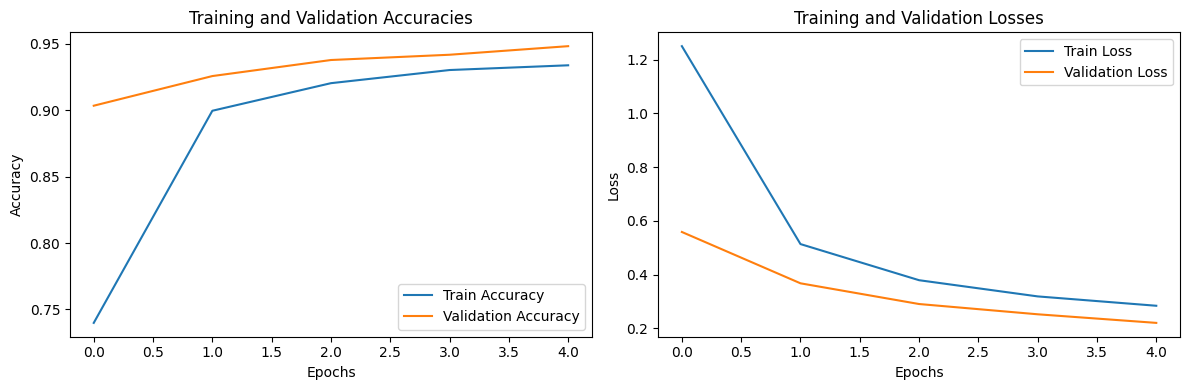

In [26]:
# Plotting the accuracy graph
epochs_range = range(epoch+1)
plt.figure(figsize=(12, 4))

# Subplot for accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracies')

# Subplot for loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')

plt.tight_layout()
plt.show()

<ipython-input-27-13d8c3ca1418>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:.0f}%'.format(x) for x in plt.gca().get_yticks()])


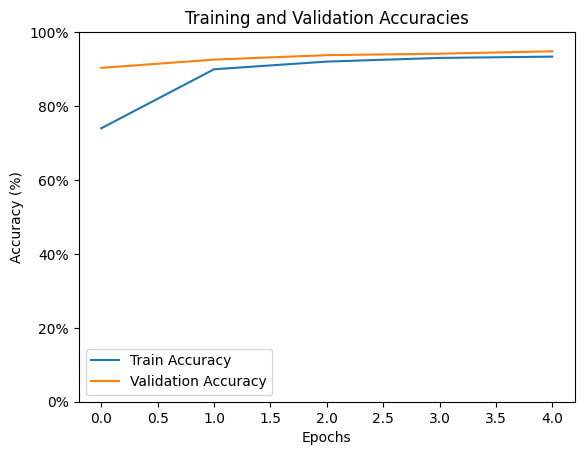

In [27]:
import matplotlib.pyplot as plt

epochs_range = range(epoch+1)
plt.plot(epochs_range, [acc * 100 for acc in train_accuracies], label='Train Accuracy')
plt.plot(epochs_range, [acc * 100 for acc in val_accuracies], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracies')

# Set y-axis lower limit to 0 and upper limit to 100
plt.ylim(0, 100)

# Format y-axis tick labels as percentages
plt.gca().set_yticklabels(['{:.0f}%'.format(x) for x in plt.gca().get_yticks()])

plt.show()


In [28]:
correct_predictions = [0] * 38  # To keep track of correct predictions for each class
total_samples = [0] * 38  # To keep track of total samples for each class

model2.eval()  # Set the model to evaluation mode

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model2(inputs)
        _, predicted = torch.max(outputs, 1)

        # Update statistics for each class
        for i in range(len(predicted)):
            total_samples[labels[i]] += 1
            if predicted[i] == labels[i]:
                correct_predictions[labels[i]] += 1

# Calculate and print performance for each class
for i in range(38):
    accuracy = correct_predictions[i] / total_samples[i] if total_samples[i] > 0 else 0
    print(f"Class {class_folders[i]}: Accuracy = {accuracy:.2%} ({correct_predictions[i]}/{total_samples[i]})")

overall_accuracy = sum(correct_predictions) / sum(total_samples)
print(f"\nOverall Accuracy: {overall_accuracy:.2%}")


Class Squash___Powdery_mildew: Accuracy = 86.51% (109/126)
Class Peach___healthy: Accuracy = 96.00% (120/125)
Class Grape___Esca_(Black_Measles): Accuracy = 89.09% (49/55)
Class Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: Accuracy = 95.74% (315/329)
Class Tomato___Late_blight: Accuracy = 99.67% (300/301)
Class Apple___Cedar_apple_rust: Accuracy = 97.16% (205/211)
Class Tomato___Septoria_leaf_spot: Accuracy = 98.84% (170/172)
Class Tomato___Target_Spot: Accuracy = 75.00% (78/104)
Class Apple___Black_rot: Accuracy = 98.33% (235/239)
Class Cherry_(including_sour)___healthy: Accuracy = 86.80% (171/197)
Class Cherry_(including_sour)___Powdery_mildew: Accuracy = 99.57% (232/233)
Class Grape___healthy: Accuracy = 94.92% (224/236)
Class Apple___Apple_scab: Accuracy = 96.04% (267/278)
Class Pepper,_bell___Bacterial_spot: Accuracy = 99.07% (214/216)
Class Apple___healthy: Accuracy = 98.84% (85/86)
Class Tomato___Tomato_mosaic_virus: Accuracy = 99.73% (1099/1102)
Class Tomato___Spider_mit

In [29]:
true_labels = []
test_predictions = []

model2.eval()  # Set the model to evaluation mode

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model2(inputs)
        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        test_predictions.extend(predicted.cpu().numpy())


In [30]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
# Calculate F1 score, precision, and recall for overall data
f1_micro = f1_score(true_labels, test_predictions, average='micro')
precision_micro, recall_micro, _, _ = precision_recall_fscore_support(true_labels, test_predictions, average='micro')

print(f"Overall Metrics:")
print(f"\t F1 Micro Score: {f1_micro:.4f}")
print(f"\t Precision Micro: {precision_micro:.4f}")
print(f"\t Recall Micro: {recall_micro:.4f}")

# Calculate confusion matrix
conf_matrix = confusion_matrix(true_labels, test_predictions, labels=range(38))

# Print or visualize the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)


Overall Metrics:
	 F1 Micro Score: 0.9447
	 Precision Micro: 0.9447
	 Recall Micro: 0.9447
Confusion Matrix:
[[ 112    3    0 ...    0    0    1]
 [   0  121    0 ...    0    0    0]
 [   3    1   50 ...    0    0    0]
 ...
 [   0    0    0 ... 1054    1    0]
 [   0    0    0 ...    1   63    0]
 [   0    0    0 ...    0    0  308]]


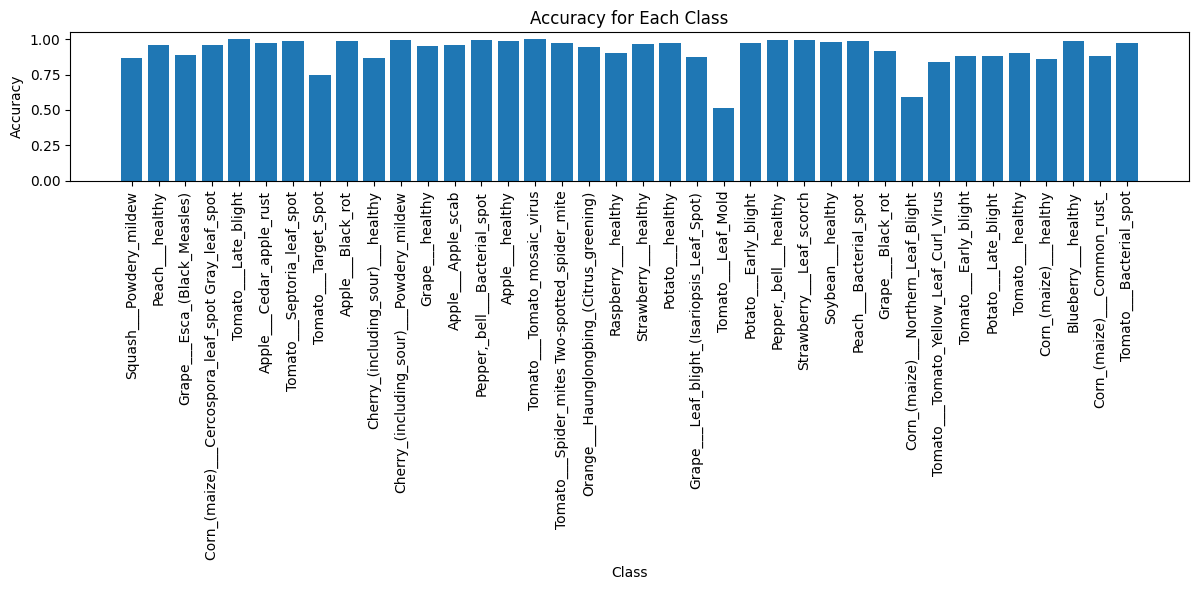

In [31]:
import matplotlib.pyplot as plt

# Calculate accuracy values for each class
class_accuracy = [correct_predictions[i] / total_samples[i] if total_samples[i] > 0 else 0 for i in range(38)]

# Plotting the bar graph
plt.figure(figsize=(12, 6))  # Adjust the figure size if needed
plt.bar(class_folders, class_accuracy)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy for Each Class')
plt.xticks(rotation=90)  # Rotate class names for better visibility
plt.tight_layout()  # Ensure labels fit within the figure
plt.show()

In [34]:
torch.save(model2.state_dict(), "/content/drive/MyDrive/Resnet/Resnet18_sgd.pth")

# Image Prediction

SGD optimizer

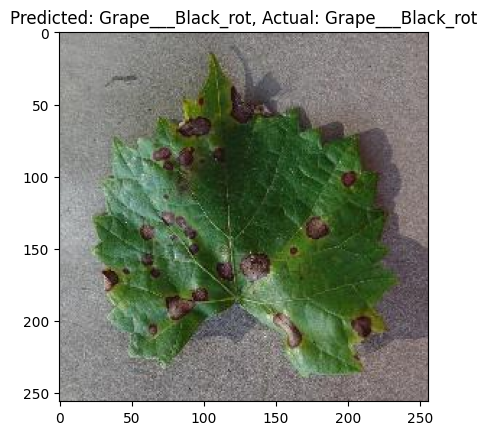

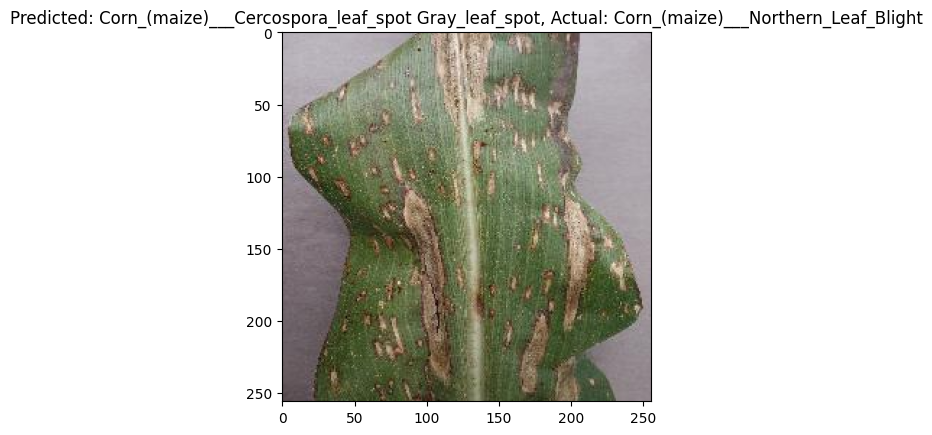

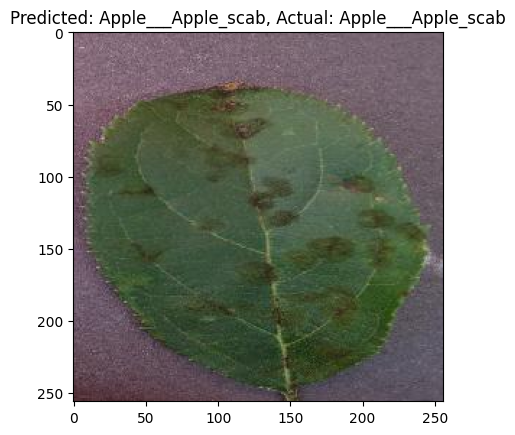

In [35]:
import torch
import matplotlib.pyplot as plt
import random

# Assuming your model is named 'model2'
# Assuming your test loader is named 'test_loader'

# Set the model to evaluation mode
model2.eval()

# Get class names
class_folders = test_loader.dataset.classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for _ in range(3):  # Display three random images
    # Get random index
    random_index = random.randint(0, len(test_loader.dataset) - 1)
    # Get data at the chosen index
    inputs, labels = test_loader.dataset[random_index]
    inputs = inputs.unsqueeze(0)  # Add a batch dimension
    inputs = inputs.to(device)  # Move the inputs to the same device as the model

    # Move the model to the same device as inputs
    model2.to(device)

    # Make predictions using the model
    with torch.no_grad():
        outputs = model2(inputs)

    # Move the outputs back to the CPU if needed
    outputs = outputs.cpu()

    # Get predicted class index
    _, predicted_idx = torch.max(outputs, 1)
    predicted_idx = predicted_idx.item()

    # Get class names
    predicted_label = class_folders[predicted_idx]
    actual_label = class_folders[labels]

    # Load and display the image
    image = inputs.squeeze().cpu().numpy().transpose((1, 2, 0))  # Convert tensor to numpy image format
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
    plt.show()


Adam optimizer

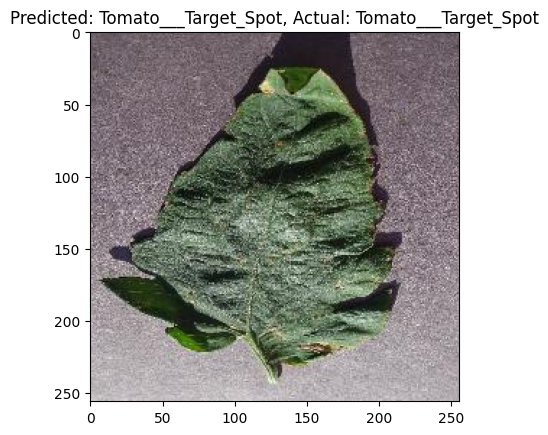

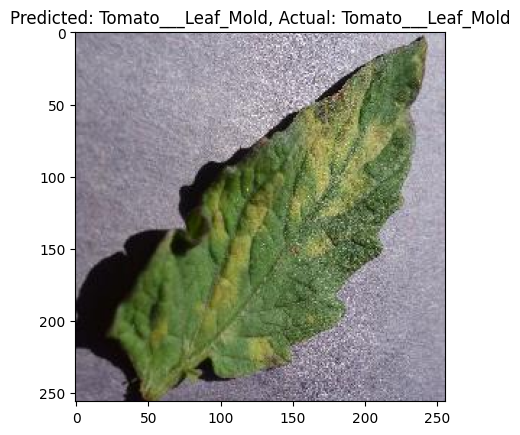

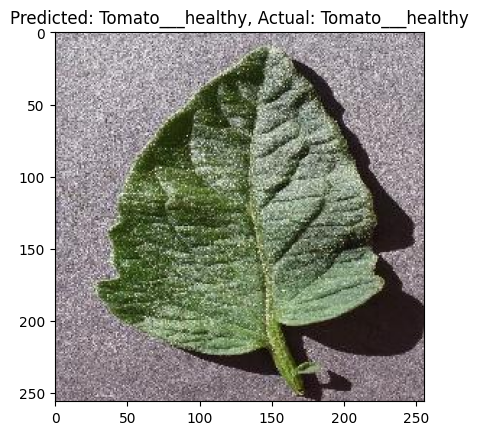

In [36]:
import torch
import matplotlib.pyplot as plt
import random

# Assuming your model is named 'model'
# Assuming your test loader is named 'test_loader'

# Set the model to evaluation mode
model.eval()

# Get class names
class_folders = test_loader.dataset.classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for _ in range(3):  # Display three random images
    # Get random index
    random_index = random.randint(0, len(test_loader.dataset) - 1)
    # Get data at the chosen index
    inputs, labels = test_loader.dataset[random_index]
    inputs = inputs.unsqueeze(0)  # Add a batch dimension
    inputs = inputs.to(device)  # Move the inputs to the same device as the model

    # Move the model to the same device as inputs
    model.to(device)

    # Make predictions using the model
    with torch.no_grad():
        outputs = model(inputs)

    # Move the outputs back to the CPU if needed
    outputs = outputs.cpu()

    # Get predicted class index
    _, predicted_idx = torch.max(outputs, 1)
    predicted_idx = predicted_idx.item()

    # Get class names
    predicted_label = class_folders[predicted_idx]
    actual_label = class_folders[labels]

    # Load and display the image
    image = inputs.squeeze().cpu().numpy().transpose((1, 2, 0))  # Convert tensor to numpy image format
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
    plt.show()


We can Predict the Data out of Data Set Upload the image and Paste the image path where you stored the image

image predict using adam optimizer

In [37]:
!pip install matplotlib pillow
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load the trained model
# model = ... (Load your trained model here)
model.eval()

# Define the transformation pipeline (similar to what you used for training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    # Add any other transformations you used during training
])
def preprocess_image(image_path):
    image = Image.open(image_path)
    image = transform(image)
    return image.unsqueeze(0)  # Add a batch dimension



In [38]:
def predict_and_display(image_path):
    image = preprocess_image(image_path)
    image = image.to(device)  # Move input data to the same device as the model
    model.to(device)  # Move the model to the same device as the input data
    with torch.no_grad():
        outputs = model(image)
        print(outputs)
    _, predicted = torch.max(outputs, 1)

    print(predicted)
    class_names = train_data.classes  # Replace with your class names
    predicted_class = class_names[predicted.item()]
    print(train_data.classes)

    plt.imshow(image.squeeze().permute(1, 2, 0).cpu())  # Move image back to CPU for display
    plt.title(f"Predicted : {predicted_class}")
    plt.axis('off')
    plt.show()

# Replace 'image_path' with the path to an image in your Google Drive



tensor([[ -3.4171,  -5.3640,  -2.1504,  -6.6778, -12.2559,   2.2710,  -8.8710,
          -9.8769, -10.4407, -11.9619,  -8.8955,  -7.1339,  -7.6332,  -7.4662,
          -4.6396,  -8.5333,  -8.6776, -14.5328, -10.9804,  -9.6597, -10.2175,
          -8.7133,  -8.3626,  -4.3390,  -8.8887,  -8.1555, -10.6788,  -9.4152,
          -9.7983,  -7.8239,  -5.7060, -10.1420,  -5.9199, -10.2670, -11.2732,
          -4.3930,  -7.7176,  -9.0214]], device='cuda:0')
tensor([5], device='cuda:0')
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Ba

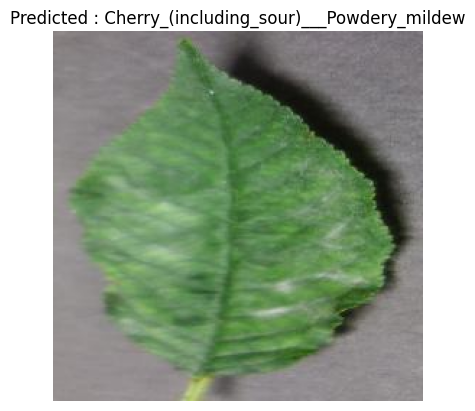

In [39]:
image_path = '/content/plantvillage/PlantVillage-Dataset-442d23a8a486febaad5c91e3c13ce30d4cd302ca/raw/color/Cherry_(including_sour)___Powdery_mildew/00705aa7-5ea2-4419-9440-8ba65e108eb9___FREC_Pwd.M 0267.JPG'
predict_and_display(image_path)